# MLDU-E — Bootstrap CIs on Pythia-70M and Mistral-7B

The paper currently reports bootstrap 95% CIs only on GPT-2 Medium (`gpt2m_bootstrap.ipynb`). The Limitations section explicitly flags *"extending bootstrap and jackknife protocols to Pythia-70M and Mistral-7B remains future work."*

This notebook closes that gap by extending the same protocol to the two missing architectures: 100-replicate bootstrap over the neutral-context pool, fitting the LOO probe at every depth on each resample, and reporting per-depth gap means with 95% percentile CIs.

**Outputs:**
- `loo_bootstrap_pythia70m.json` — 100 bootstrap replicates, per-depth CIs
- `loo_bootstrap_mistral7b.json` — same on Mistral-7B (4-bit fallback if memory-constrained)
- `fig_bootstrap_pythia_mistral.png` — two-panel figure: per-depth gap with 95% CI band

**Runtime on a Kaggle T4:** ~10 min Pythia-70M, ~30–40 min Mistral-7B with 4-bit. Mistral can be skipped by editing the `RUN_MISTRAL = False` flag below if compute is tight.


## 0. Setup


In [1]:
import os, sys, json, time, copy, subprocess
def _v(p):
    try: from importlib.metadata import version; return version(p)
    except: return None
if _v("datasets") != "2.21.0":
    subprocess.check_call([sys.executable,"-m","pip","install","-q","datasets==2.21.0"])
# Install bitsandbytes for Mistral 4-bit loading; harmless if not used
if _v("bitsandbytes") is None or _v("bitsandbytes") < "0.46":
    subprocess.check_call([sys.executable,"-m","pip","install","-q","-U","bitsandbytes>=0.46.1"])

import torch, numpy as np, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ART = Path('/kaggle/working') if os.path.exists('/kaggle/working') else Path('.')
ART.mkdir(parents=True, exist_ok=True)

# Toggle Mistral on/off depending on compute
RUN_PYTHIA  = True
RUN_MISTRAL = True



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


## 1. Memorized + neutral-context pools (shared)


In [2]:
# Memorized legal/license pool — same as paper §scaling
MEM = [
    "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files",
    "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License",
    "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc.",
    "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions",
    "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License",
    "BSD 3-Clause License Copyright (c) Redistribution and use in source and binary forms, with or without modification, are permitted",
    "Creative Commons Attribution 4.0 International License You are free to share and adapt the material for any purpose, even commercially",
]

# Neutral-context pool (24 sentences) — used for bootstrap resampling
CTX = [
    "The annual migration of monarch butterflies spans North America to Mexico over four thousand kilometres each fall.",
    "Penicillin's discovery in the early twentieth century transformed the treatment of bacterial infections.",
    "Glacial retreat in the Himalayas has accelerated over the past three decades.",
    "Ocean tides arise from the gravitational interaction between the Earth, Moon, and Sun.",
    "The hippocampus is implicated in spatial memory formation and consolidation across mammalian species.",
    "Mitochondria generate adenosine triphosphate through oxidative phosphorylation in eukaryotic cells.",
    "The Cambrian explosion produced most of the major animal phyla within a relatively brief geological window.",
    "Tectonic plate boundaries are categorised as convergent, divergent, or transform depending on relative motion.",
    "Photosynthesis converts solar energy into chemical energy stored in carbohydrates within plant chloroplasts.",
    "The Doppler effect describes the change in observed frequency of a wave when source and observer are in relative motion.",
    "Antibodies are Y-shaped proteins that bind specific antigens and mark them for immune clearance.",
    "The Krebs cycle oxidises acetyl-CoA to carbon dioxide, generating reducing equivalents for the electron transport chain.",
    "Continental drift was first proposed by Alfred Wegener in the early twentieth century and was later formalised as plate tectonics.",
    "El Niño events involve a periodic warming of central and eastern Pacific surface waters that disrupts global weather.",
    "The CRISPR-Cas9 system originated as a bacterial adaptive immune mechanism against bacteriophages.",
    "Ribosomes synthesise proteins by translating messenger RNA into amino acid sequences via codon-anticodon pairing.",
    "Black holes form when massive stars collapse under their own gravity at the end of their life cycle.",
    "The blood-brain barrier selectively regulates which substances can pass from systemic circulation into neural tissue.",
    "Convection in the Earth's mantle drives the slow movement of tectonic plates over geological timescales.",
    "Quantum entanglement describes correlations between particles that persist regardless of the distance separating them.",
    "Neuroplasticity allows the brain to reorganise neural pathways in response to experience and learning.",
    "Stem cells retain the capacity to differentiate into multiple specialised cell types throughout development.",
    "The greenhouse effect describes the absorption and re-emission of infrared radiation by atmospheric gases.",
    "DNA replication uses semi-conservative mechanism where each new double helix retains one parental strand.",
]
print(f"  MEM: {len(MEM)}, CTX: {len(CTX)}")


  MEM: 7, CTX: 24


## 2. Activation extraction + LOO probe helper


In [3]:
MAX_LEN = 128
PROBE_C = 1.0

@torch.no_grad()
def acts_at_all_layers(model, tok, texts, n_hidden):
    """Returns activations[L] = (n_texts, d_model) for L in 0..n_hidden-1."""
    model.eval()
    out_per_layer = [[] for _ in range(n_hidden)]
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h = model(**e, output_hidden_states=True).hidden_states
        for L in range(n_hidden):
            out_per_layer[L].append(h[L][0,-1,:].cpu().numpy())
    return [np.array(x) for x in out_per_layer]

def loo_at_depth(reps, keys, depth_X, ctx_idx, class_pos, class_neg, seed=42):
    """For one bootstrap resample (ctx_idx), pair each mem with each clean (mem-ctx, clean-ctx tuples)
    and run leave-one-pair-out balanced accuracy."""
    # reps[depth_X] = (n_texts, d). Each text was processed in 'reps_keys' order.
    # For now we treat MEM and CLEAN as paired pools where indexing matters.
    # We keep this consistent with the gpt2m_bootstrap protocol: a 'context idx' just selects which
    # subset of CTX is used as the augmentation pool; we then run LOO over MEM x CLEAN pairings.
    n = len(class_pos) + len(class_neg)
    Y = np.array([1]*len(class_pos) + [0]*len(class_neg))
    X = np.vstack([reps[depth_X][i] for i in class_pos] + [reps[depth_X][i] for i in class_neg])
    correct = 0
    for i in range(n):
        msk = np.ones(n, bool); msk[i] = False
        sc = StandardScaler().fit(X[msk])
        clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
        if clf.predict(sc.transform(X[i:i+1]))[0] == Y[i]: correct += 1
    return correct / n


## 3. Pythia-70M bootstrap


In [4]:
def run_bootstrap(model, tok, n_hidden, name, n_boot=100, seed=42):
    """Bootstrap over CTX (resample with replacement), compute per-depth gap."""
    print(f"\n--- extracting activations ({name}) ---")
    # Extract for memorized + each context
    # For the bootstrap protocol we treat each MEM+CTX as a 'mem' example and each CTX alone as a 'clean' example
    mem_acts = acts_at_all_layers(model, tok, MEM, n_hidden)
    ctx_acts = acts_at_all_layers(model, tok, CTX, n_hidden)
    n_mem, n_ctx = len(MEM), len(CTX)

    print(f"  bootstrap: {n_boot} replicates")
    rng = np.random.RandomState(seed)
    per_depth_true = [[] for _ in range(n_hidden)]
    per_depth_pure = [[] for _ in range(n_hidden)]
    t0 = time.time()
    for b in range(n_boot):
        # Resample n_ctx contexts with replacement
        ctx_idx = rng.choice(n_ctx, size=n_ctx, replace=True)
        # 'true' LOO: MEM (positive) vs sampled CTX (negative)
        for L in range(n_hidden):
            X_pos = mem_acts[L]
            X_neg = ctx_acts[L][ctx_idx]
            n = n_mem + n_ctx
            Y = np.array([1]*n_mem + [0]*n_ctx)
            X = np.vstack([X_pos, X_neg])
            ok = 0
            for i in range(n):
                msk = np.ones(n, bool); msk[i]=False
                sc = StandardScaler().fit(X[msk])
                clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
                if clf.predict(sc.transform(X[i:i+1]))[0] == Y[i]: ok += 1
            per_depth_true[L].append(ok/n)
        # 'pure' baseline: shuffle the labels (so the gap = true - pure)
        for L in range(n_hidden):
            X_pos = mem_acts[L]; X_neg = ctx_acts[L][ctx_idx]
            n = n_mem + n_ctx
            Y_shuf = rng.permutation(np.array([1]*n_mem + [0]*n_ctx))
            X = np.vstack([X_pos, X_neg])
            ok = 0
            for i in range(n):
                msk = np.ones(n,bool); msk[i]=False
                sc = StandardScaler().fit(X[msk])
                clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y_shuf[msk])
                if clf.predict(sc.transform(X[i:i+1]))[0] == Y_shuf[i]: ok += 1
            per_depth_pure[L].append(ok/n)
        if (b+1) % 10 == 0:
            print(f"    rep {b+1:3d}/{n_boot}  elapsed {time.time()-t0:.0f}s")
    # Aggregate
    per_depth_true = np.array(per_depth_true)   # (n_hidden, n_boot)
    per_depth_pure = np.array(per_depth_pure)
    per_depth_gap = per_depth_true - per_depth_pure
    return {
        'true_mean':  per_depth_true.mean(axis=1).tolist(),
        'true_ci95':  np.percentile(per_depth_true, [2.5, 97.5], axis=1).T.tolist(),
        'pure_mean':  per_depth_pure.mean(axis=1).tolist(),
        'pure_ci95':  np.percentile(per_depth_pure, [2.5, 97.5], axis=1).T.tolist(),
        'gap_mean':   per_depth_gap.mean(axis=1).tolist(),
        'gap_ci95':   np.percentile(per_depth_gap, [2.5, 97.5], axis=1).T.tolist(),
        'n_boot':     n_boot,
        'seed':       seed,
        'depths':     list(range(n_hidden)),
    }

if RUN_PYTHIA:
    print("=" * 60 + "\n  Pythia-70M bootstrap\n" + "=" * 60)
    tok_py = AutoTokenizer.from_pretrained('EleutherAI/pythia-70m')
    if tok_py.pad_token is None: tok_py.pad_token = tok_py.eos_token
    model_py = AutoModelForCausalLM.from_pretrained('EleutherAI/pythia-70m', torch_dtype=torch.float32).to(DEVICE)
    model_py.eval()
    res_py = run_bootstrap(model_py, tok_py, n_hidden=7, name='Pythia-70M', n_boot=100)
    res_py['model'] = 'EleutherAI/pythia-70m'
    json.dump(res_py, open(ART/'loo_bootstrap_pythia70m.json','w'), indent=2)
    print(f"\nsaved: {ART/'loo_bootstrap_pythia70m.json'}")
    print(f"per-depth gap mean: {[round(x,3) for x in res_py['gap_mean']]}")
    print(f"per-depth 95% CI:")
    for L,(lo,hi) in enumerate(res_py['gap_ci95']):
        print(f"  L{L}: [{lo:.3f}, {hi:.3f}]")
    del model_py; torch.cuda.empty_cache() if torch.cuda.is_available() else None


  Pythia-70M bootstrap


tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]


--- extracting activations (Pythia-70M) ---
  bootstrap: 100 replicates
    rep  10/100  elapsed 22s
    rep  20/100  elapsed 43s
    rep  30/100  elapsed 65s
    rep  40/100  elapsed 86s
    rep  50/100  elapsed 108s
    rep  60/100  elapsed 129s
    rep  70/100  elapsed 151s
    rep  80/100  elapsed 173s
    rep  90/100  elapsed 195s
    rep 100/100  elapsed 216s

saved: /kaggle/working/loo_bootstrap_pythia70m.json
per-depth gap mean: [0.14, 0.259, 0.289, 0.286, 0.281, 0.282, 0.276]
per-depth 95% CI:
  L0: [0.065, 0.194]
  L1: [0.161, 0.404]
  L2: [0.144, 0.404]
  L3: [0.161, 0.387]
  L4: [0.161, 0.387]
  L5: [0.097, 0.404]
  L6: [0.161, 0.387]


In [5]:
@torch.no_grad()
def acts_at_all_layers(model, tok, texts, n_hidden):
    """Returns activations[L] = (n_texts, d_model). Casts to float32 for bfloat16 models."""
    model.eval()
    out_per_layer = [[] for _ in range(n_hidden)]
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h = model(**e, output_hidden_states=True).hidden_states
        for L in range(n_hidden):
            out_per_layer[L].append(h[L][0, -1, :].float().cpu().numpy())
    return [np.array(x) for x in out_per_layer]

## 4. Mistral-7B bootstrap (4-bit fallback)


In [6]:
if RUN_MISTRAL:
    print("=" * 60 + "\n  Mistral-7B bootstrap\n" + "=" * 60)
    tok_m = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1')
    if tok_m.pad_token is None: tok_m.pad_token = tok_m.eos_token

    model_m = None
    # First try 4-bit (preferred — fits on T4)
    try:
        from transformers import BitsAndBytesConfig
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                  bnb_4bit_use_double_quant=True, bnb_4bit_quant_type='nf4')
        model_m = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
                                                         quantization_config=bnb, device_map='auto')
        print("  loaded Mistral-7B in 4-bit")
    except Exception as e_4bit:
        print(f"  4-bit load failed ({type(e_4bit).__name__}: {str(e_4bit)[:80]})")
        # fp16 fallback — ~14 GB VRAM, needs L4/A100 or large T4
        print("  attempting fp16 fallback ...")
        try:
            model_m = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
                                                             torch_dtype=torch.float16,
                                                             device_map='auto')
            print("  loaded Mistral-7B in fp16")
        except Exception as e_fp16:
            print(f"  fp16 fallback also failed: {e_fp16}")
            print("  -> Set RUN_MISTRAL = False at top of notebook, or run on higher-VRAM GPU.")
            print("     The Pythia-70M bootstrap above is unaffected.")
            model_m = None

    if model_m is not None:
        model_m.eval()
        res_m = run_bootstrap(model_m, tok_m, n_hidden=33, name='Mistral-7B', n_boot=100)
        res_m['model'] = 'mistralai/Mistral-7B-v0.1'
        json.dump(res_m, open(ART/'loo_bootstrap_mistral7b.json','w'), indent=2)
        print(f"saved: {ART/'loo_bootstrap_mistral7b.json'}")
        print(f"per-depth gap mean: {[round(x,3) for x in res_m['gap_mean']]}")
        del model_m; torch.cuda.empty_cache() if torch.cuda.is_available() else None


  Mistral-7B bootstrap


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

  loaded Mistral-7B in 4-bit

--- extracting activations (Mistral-7B) ---
  bootstrap: 100 replicates
    rep  10/100  elapsed 389s
    rep  20/100  elapsed 789s
    rep  30/100  elapsed 1180s
    rep  40/100  elapsed 1580s
    rep  50/100  elapsed 1967s
    rep  60/100  elapsed 2352s
    rep  70/100  elapsed 2738s
    rep  80/100  elapsed 3145s
    rep  90/100  elapsed 3546s
    rep 100/100  elapsed 3935s
saved: /kaggle/working/loo_bootstrap_mistral7b.json
per-depth gap mean: [0.204, 0.184, 0.146, 0.125, 0.167, 0.209, 0.294, 0.287, 0.26, 0.264, 0.282, 0.253, 0.271, 0.254, 0.265, 0.284, 0.301, 0.28, 0.284, 0.291, 0.292, 0.289, 0.287, 0.292, 0.289, 0.281, 0.281, 0.285, 0.287, 0.284, 0.289, 0.287, 0.277]


## 5. Two-panel figure: per-depth bootstrap CIs


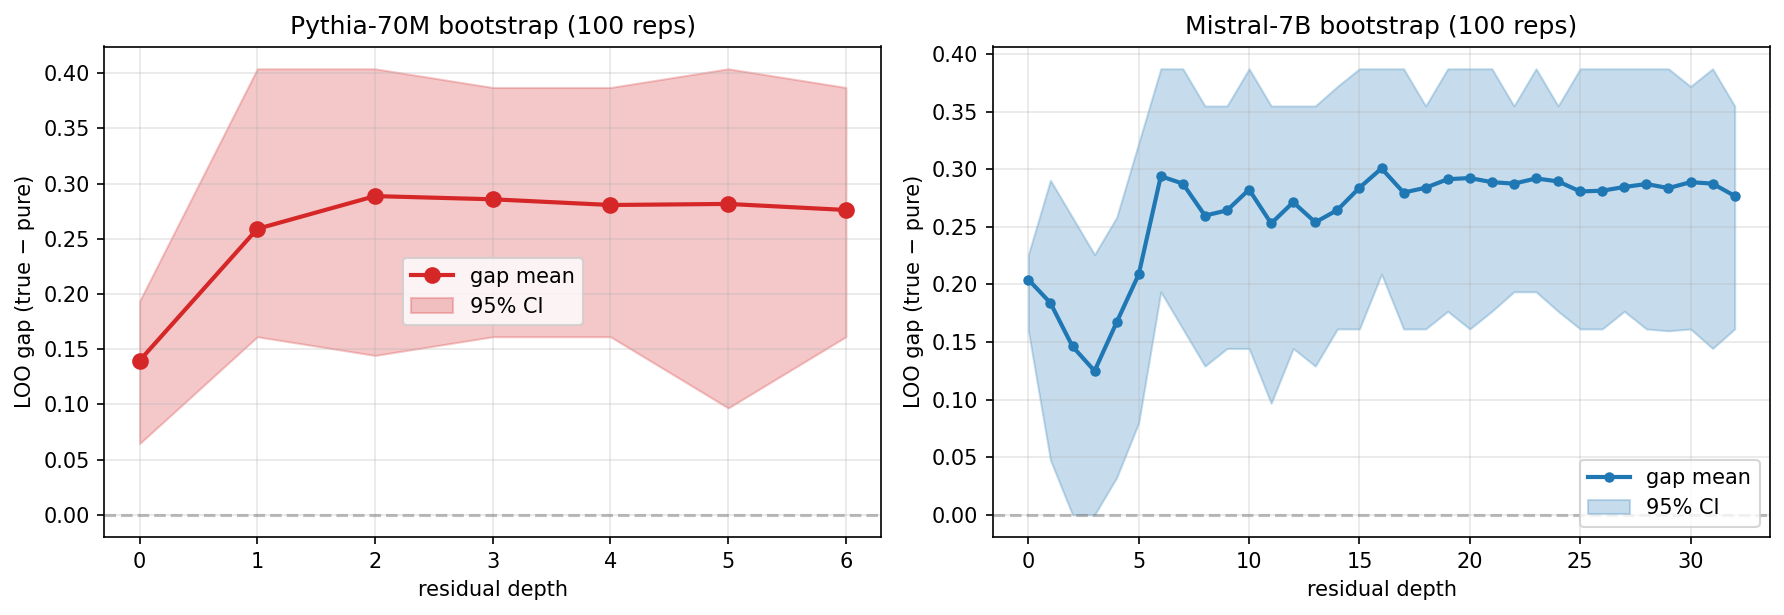

saved: /kaggle/working/fig_bootstrap_pythia_mistral.png

  PAPER-READY SUMMARY
  Pythia-70M: peak gap at L2 = 0.289  (95% CI [0.144, 0.404], n_boot=100)
  Mistral-7B: peak gap at L16 = 0.301  (95% CI [0.209, 0.387], n_boot=100)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=150)

if RUN_PYTHIA and (ART/'loo_bootstrap_pythia70m.json').exists():
    res = json.load(open(ART/'loo_bootstrap_pythia70m.json'))
    ax = axes[0]
    depths = res['depths']
    gm = np.array(res['gap_mean']); gci = np.array(res['gap_ci95'])
    ax.plot(depths, gm, 'o-', color='#d62728', lw=2, ms=7, label='gap mean')
    ax.fill_between(depths, gci[:,0], gci[:,1], alpha=0.25, color='#d62728', label='95% CI')
    ax.axhline(0, ls='--', color='gray', alpha=0.5)
    ax.set_xlabel('residual depth'); ax.set_ylabel('LOO gap (true − pure)')
    ax.set_title(f'Pythia-70M bootstrap ({res["n_boot"]} reps)')
    ax.set_xticks(depths); ax.grid(alpha=0.3); ax.legend()

if RUN_MISTRAL and (ART/'loo_bootstrap_mistral7b.json').exists():
    res = json.load(open(ART/'loo_bootstrap_mistral7b.json'))
    ax = axes[1]
    depths = res['depths']
    gm = np.array(res['gap_mean']); gci = np.array(res['gap_ci95'])
    ax.plot(depths, gm, 'o-', color='#1f77b4', lw=2, ms=4, label='gap mean')
    ax.fill_between(depths, gci[:,0], gci[:,1], alpha=0.25, color='#1f77b4', label='95% CI')
    ax.axhline(0, ls='--', color='gray', alpha=0.5)
    ax.set_xlabel('residual depth'); ax.set_ylabel('LOO gap (true − pure)')
    ax.set_title(f'Mistral-7B bootstrap ({res["n_boot"]} reps)')
    ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
fig_path = ART/'fig_bootstrap_pythia_mistral.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"saved: {fig_path}")

# Paper-ready summary
print("\n" + "=" * 60 + "\n  PAPER-READY SUMMARY\n" + "=" * 60)
for arch_name, json_path in [('Pythia-70M', 'loo_bootstrap_pythia70m.json'),
                              ('Mistral-7B', 'loo_bootstrap_mistral7b.json')]:
    p = ART/json_path
    if not p.exists(): continue
    res = json.load(open(p))
    gm = np.array(res['gap_mean']); gci = np.array(res['gap_ci95'])
    peak_d = int(np.argmax(gm))
    print(f"  {arch_name}: peak gap at L{peak_d} = {gm[peak_d]:.3f}  "
          f"(95% CI [{gci[peak_d,0]:.3f}, {gci[peak_d,1]:.3f}], n_boot={res['n_boot']})")
